In [1]:
import torch
import numpy as np

epsilon = 0.001 # epsilon = 10^-3
so_chieu = 3 # n = 3
alpha = 0.01 # learning rate 
so_vong_lap = 1000 # so vong lap 
so_chuong_trinh = 20
mien_duoi, mien_tren = -5.12, 5.12 
final_values = []
def rastrigin(x):
    n = x.shape[0]
    return 10 * n + torch.sum(x ** 2 - 10 * torch.cos(2 * np.pi * x))

for chuong_trinh in range(so_chuong_trinh):
    x = torch.rand(so_chieu) * (mien_tren - mien_duoi) - mien_tren
    x.requires_grad = True
    for vong_lap in range(so_vong_lap):
        f_x = rastrigin(x)
        #dao ham f(x)
        f_x.backward()
        gradient = x.grad.clone()
        #dieu kien dung norm 
        if torch.norm(gradient) < epsilon:
            break 
        
        #cap nhat x1, x2, x3 
        with torch.no_grad():
            x -= alpha * gradient 
            x.clamp(mien_duoi, mien_tren)
        
        #reset gradient de khong bi cong don vo grad truoc do
        x.grad.zero_()
    
    #them ham muc tieu cuoi cung cua moi lan chay
    with torch.no_grad():
        final_value = rastrigin(x).item()
        final_values.append(final_value)
    
    print(f"lan chay {chuong_trinh + 1 :2d}: so vong lap = {vong_lap + 1 :4d}, "
          f"final f(x) = {final_value:.6f} " 
          f"x1 = {x[0].item():.4f}, x2 = {x[1].item():.4f}, x3 = {x[2].item():.4f} "
          f"gradient norm = {torch.norm(gradient).item():.6f}")
    
print("=" * 70)
print("thong ke ket qua:")
print(f"Min = {np.min(final_values):.4f}")
print(f"Max = {np.max(final_values):.4f}")
print(f"Mean = {np.mean(final_values):.4f}")
print(f"Std = {np.std(final_values):.4f}")


        
        


lan chay  1: so vong lap = 1000, final f(x) = 62.576305 x1 = 3.2382, x2 = 3.3101, x3 = -2.7392 gradient norm = 98.939949
lan chay  2: so vong lap = 1000, final f(x) = 27.330143 x1 = -1.8346, x2 = -2.9818, x3 = -2.9081 gradient norm = 61.164612
lan chay  3: so vong lap = 1000, final f(x) = 40.171665 x1 = -0.3223, x2 = 2.7298, x3 = -0.2002 gradient norm = 101.696236
lan chay  4: so vong lap = 1000, final f(x) = 56.373466 x1 = 2.3613, x2 = -2.8429, x3 = -2.6731 gradient norm = 74.983223
lan chay  5: so vong lap = 1000, final f(x) = 27.420153 x1 = 1.7826, x2 = -0.3541, x3 = -0.0185 gradient norm = 84.343887
lan chay  6: so vong lap = 1000, final f(x) = 36.294384 x1 = 2.9620, x2 = -2.7789, x3 = -2.8717 gradient norm = 43.641422
lan chay  7: so vong lap = 1000, final f(x) = 45.504120 x1 = 0.9326, x2 = 2.7344, x3 = -2.5848 gradient norm = 93.836594
lan chay  8: so vong lap = 1000, final f(x) = 44.844044 x1 = -3.3334, x2 = -1.0263, x3 = -2.7504 gradient norm = 91.889458
lan chay  9: so vong la

In [2]:
x = torch.tensor([1.0, -1.5, 0.5], requires_grad= True)
final_values = []
for i in range (4):
    f_x = rastrigin(x)
    f_x.backward()
    gradient = x.grad.clone()
    norm = torch.norm(gradient)
    print("=" * 100)
    print(f"lan {i:1d}")
    print(f"x1 = {x[0].item():.4f}, x2 = {x[1].item():.4f}, x3 = {x[2].item():.4f}")
    print(f"grad_x1 = {gradient[0].item():.4f}, grad_x2 = {gradient[1].item():.4f}, grad_x3 = {gradient[2].item():.4f}")
    print(f"norm = {norm:.6f}")
    print(f"f(x) = {final_value:.6f}")

    with torch.no_grad():
        x -= alpha * gradient
        x.clamp(mien_duoi, mien_tren)
        final_value = rastrigin(x).item()
        final_values.append(final_value)
    
    x.grad.zero_()
    
    
    





lan 0
x1 = 1.0000, x2 = -1.5000, x3 = 0.5000
grad_x1 = 2.0000, grad_x2 = -3.0000, grad_x3 = 1.0000
norm = 3.741661
f(x) = 48.188873
lan 1
x1 = 0.9800, x2 = -1.4700, x3 = 0.4900
grad_x1 = -5.9149, grad_x2 = -14.7135, grad_x3 = 4.9252
norm = 16.605125
f(x) = 43.243393
lan 2
x1 = 1.0391, x2 = -1.3229, x3 = 0.4407
grad_x1 = 17.3784, grad_x2 = -59.0068, grad_x3 = 23.7366
norm = 65.933632
f(x) = 37.060047
lan 3
x1 = 0.8654, x2 = -0.7328, x3 = 0.2034
grad_x1 = -45.3047, grad_x2 = 60.9996, grad_x3 = 60.5624
norm = 97.166222
f(x) = 22.888268


Lan chay  1: Iterations = 1000, Final f(x) = 41.280800, x = [0.6707, -2.5510, 0.0162]
Lan chay  2: Iterations = 1000, Final f(x) = 57.353882, x = [-3.2136, 2.6333, 1.3144]
Lan chay  3: Iterations = 1000, Final f(x) = 52.903942, x = [1.2006, 2.7847, 5.1200]
Lan chay  4: Iterations = 1000, Final f(x) = 57.539757, x = [-2.7136, -1.8214, -5.1200]
Lan chay  5: Iterations = 1000, Final f(x) = 55.781433, x = [-2.7254, 2.6944, 3.1843]
Lan chay  6: Iterations = 1000, Final f(x) = 71.314102, x = [0.5780, 3.3314, 2.5373]
Lan chay  7: Iterations = 1000, Final f(x) = 69.939514, x = [-4.8240, 1.3785, -2.3615]
Lan chay  8: Iterations = 1000, Final f(x) = 51.589149, x = [-2.6753, -2.6731, -1.8382]
Lan chay  9: Iterations = 1000, Final f(x) = 39.923775, x = [1.3479, 2.3590, -0.0477]
Lan chay 10: Iterations = 1000, Final f(x) = 44.544708, x = [-2.5469, 1.1937, -3.0744]
Lan chay 11: Iterations = 1000, Final f(x) = 46.326374, x = [-1.8300, 3.3303, 1.7701]
Lan chay 12: Iterations = 1000, Final f(x) = 26.18

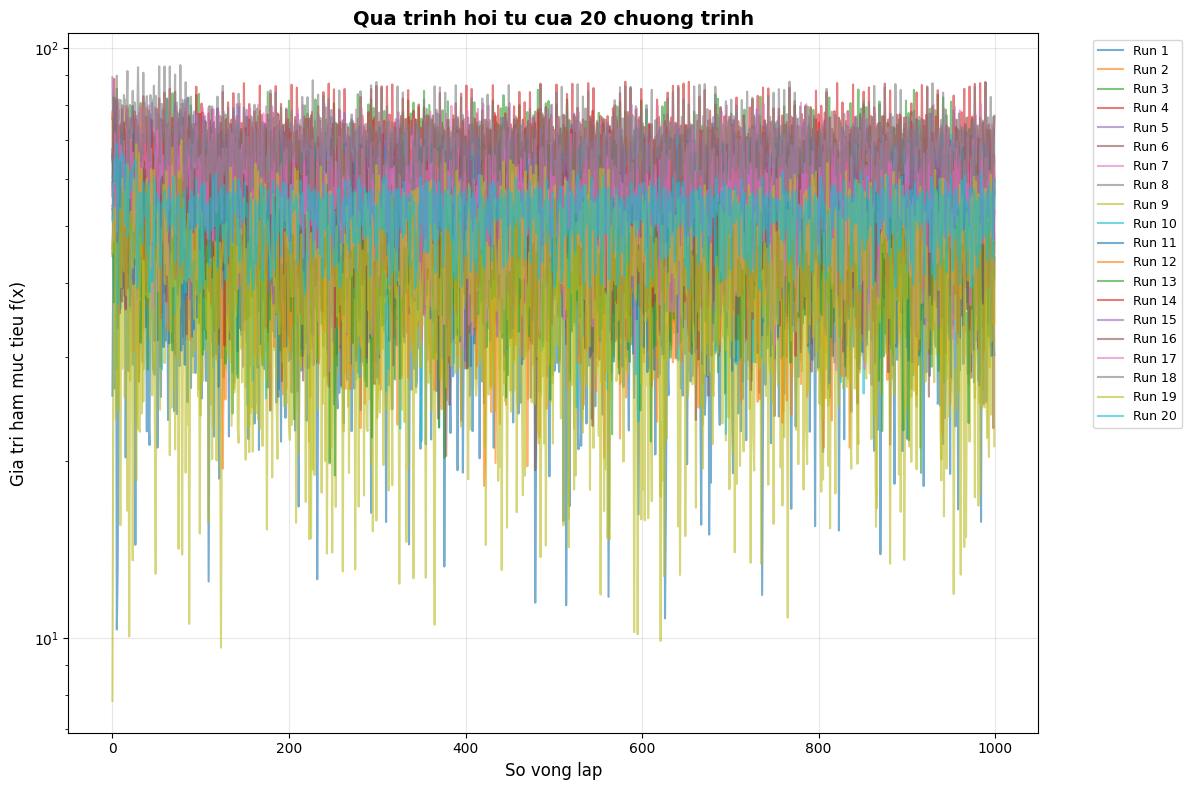

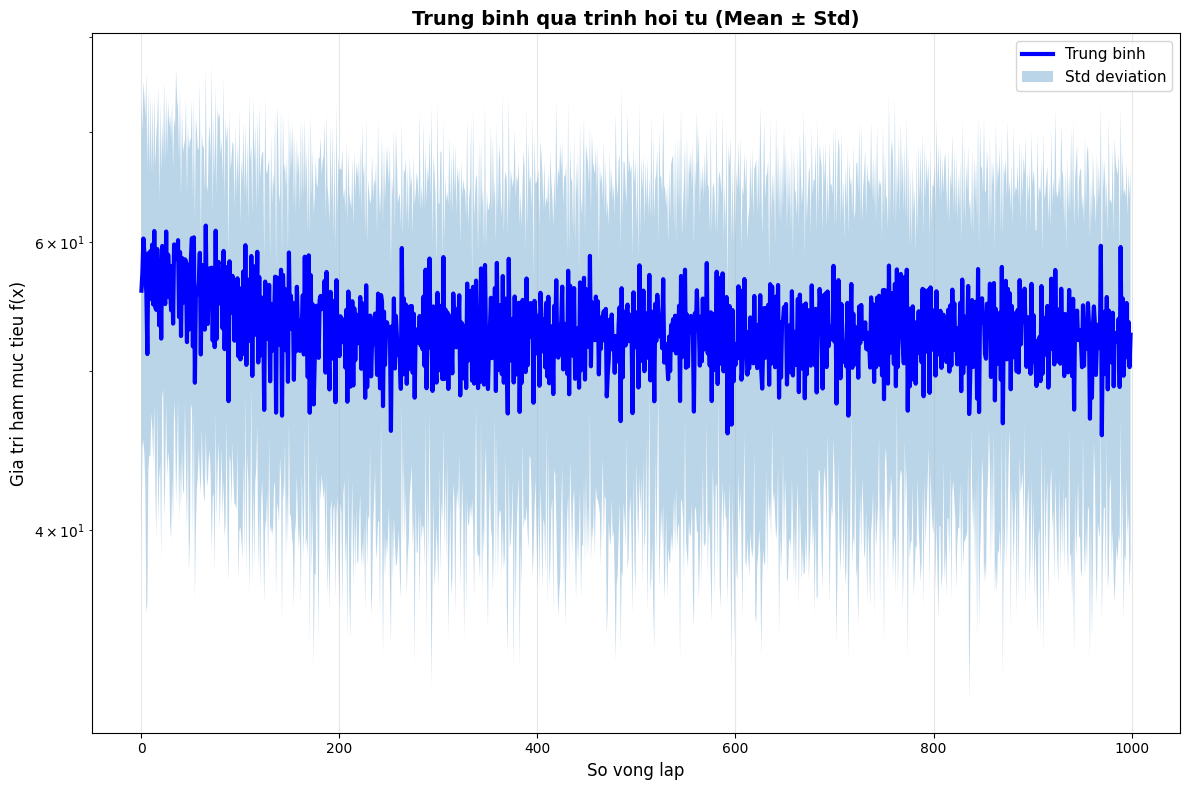

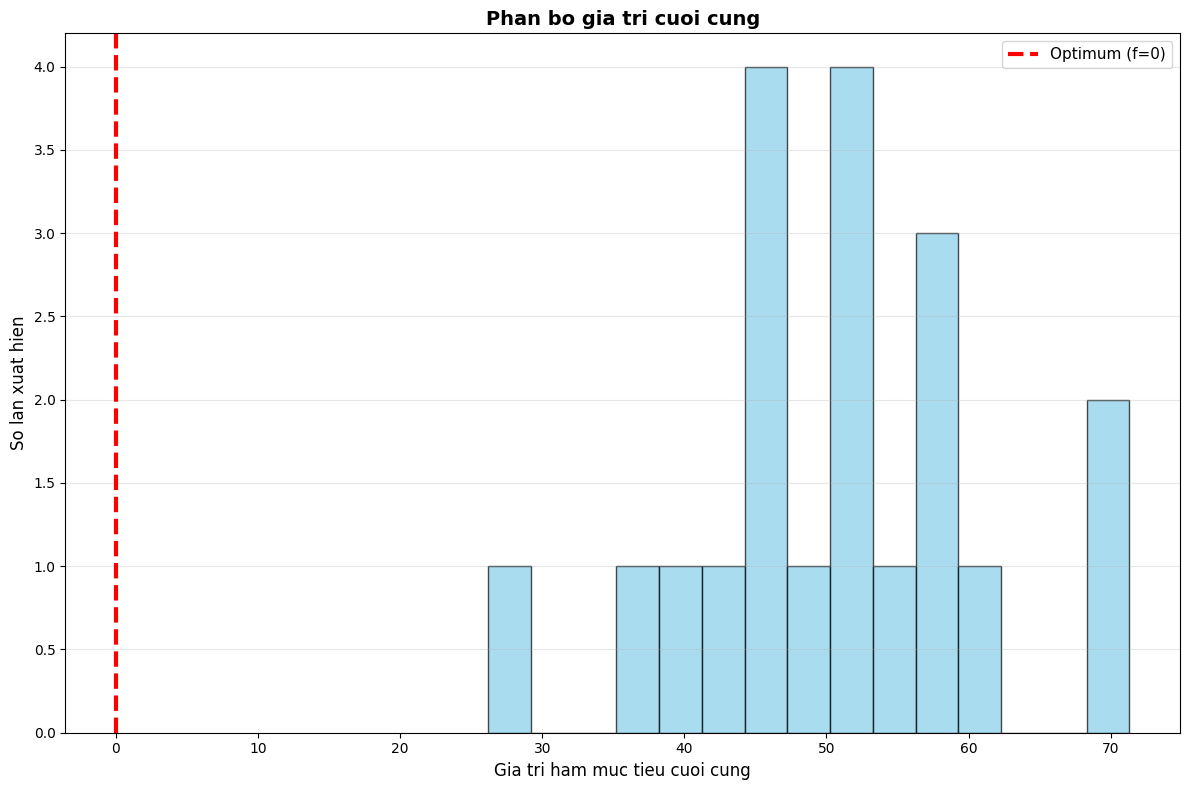

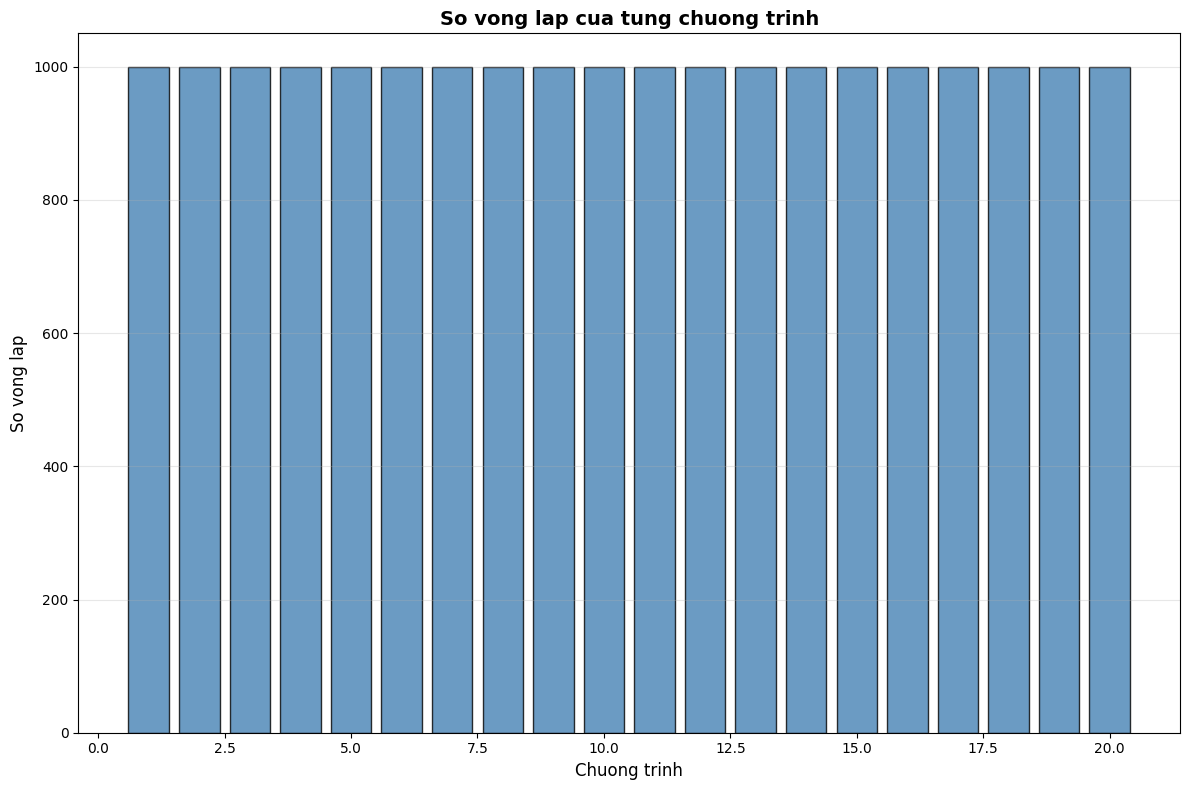


NHAN XET VE CHAT LUONG THUAT TOAN:

1. TOC DO HOI TU:
   - Trung binh: 1000.0 vong lap
   - Min: 1000, Max: 1000
   => Hoi tu CHAM

2. DO ON DINH:
   - Do lech chuan ket qua cuoi: 10.472825
   => ON DINH TRUNG BINH

3. KHA NANG TIM NGHIEM TOAN CUC:
   - Gia tri tot nhat: 26.181019 (optimum = 0)
   - Ti le dat f(x) < 1.0: 0.0%
   => YEU - Thuong xuyen mac ket tai local minima

4. KET LUAN:
   * Ham Rastrigin co NHIEU local minima
   * Gradient Descent thuong chi tim duoc local minima
   * Can cac phuong phap toi uu toan cuc (GA, PSO, SA, ...)
   * Nen thu nghiem voi learning rate khac nhau


In [3]:
import matplotlib.pyplot as plt

# Lưu lịch sử hội tụ của từng chương trình
convergence_histories = []
final_values = []
num_iterations_list = []

for chuong_trinh in range(so_chuong_trinh):
    x = torch.rand(so_chieu) * (mien_tren - mien_duoi) + mien_duoi
    x.requires_grad = True
    
    # Lưu lịch sử f(x) của chương trình này
    history = []
    
    for vong_lap in range(so_vong_lap):
        f_x = rastrigin(x)
        history.append(f_x.item())
        
        f_x.backward()
        gradient = x.grad.clone()
        
        if torch.norm(gradient) < epsilon:
            break
        
        with torch.no_grad():
            x -= alpha * gradient
            x.clamp_(mien_duoi, mien_tren)
        
        x.grad.zero_()
    
    # Lưu kết quả cuối cùng
    with torch.no_grad():
        final_value = rastrigin(x).item()
    
    convergence_histories.append(history)
    final_values.append(final_value)
    num_iterations_list.append(vong_lap + 1)
    
    print(f"Lan chay {chuong_trinh + 1:2d}: Iterations = {vong_lap + 1:4d}, "
          f"Final f(x) = {final_value:.6f}, "
          f"x = [{x[0].item():.4f}, {x[1].item():.4f}, {x[2].item():.4f}]")

print("=" * 70)
print("THONG KE KET QUA:")
print(f"Min:  {np.min(final_values):.6f}")
print(f"Max:  {np.max(final_values):.6f}")
print(f"Mean: {np.mean(final_values):.6f}")
print(f"Std:  {np.std(final_values):.6f}")
print(f"So lan dat f(x) < 1.0: {sum(1 for v in final_values if v < 1.0)}/{so_chuong_trinh}")

# ĐỒ THỊ 1: Quá trình hội tụ của tất cả 20 chương trình
plt.figure(figsize=(12, 8))
for i, history in enumerate(convergence_histories):
    plt.plot(history, alpha=0.6, linewidth=1.5, label=f'Run {i+1}')
plt.xlabel('So vong lap', fontsize=12)
plt.ylabel('Gia tri ham muc tieu f(x)', fontsize=12)
plt.title('Qua trinh hoi tu cua 20 chuong trinh', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('do_thi_1_hoi_tu.png', dpi=300, bbox_inches='tight')
plt.show()

# ĐỒ THỊ 2: Trung bình và độ lệch chuẩn
plt.figure(figsize=(12, 8))
max_len = max(len(h) for h in convergence_histories)
avg_convergence = []
std_convergence = []

for iter_idx in range(max_len):
    values = [h[iter_idx] if iter_idx < len(h) else h[-1] 
              for h in convergence_histories]
    avg_convergence.append(np.mean(values))
    std_convergence.append(np.std(values))

avg_convergence = np.array(avg_convergence)
std_convergence = np.array(std_convergence)

plt.plot(avg_convergence, 'b-', linewidth=3, label='Trung binh')
plt.fill_between(range(max_len), 
                  avg_convergence - std_convergence,
                  avg_convergence + std_convergence,
                  alpha=0.3, label='Std deviation')
plt.xlabel('So vong lap', fontsize=12)
plt.ylabel('Gia tri ham muc tieu f(x)', fontsize=12)
plt.title('Trung binh qua trinh hoi tu (Mean ± Std)', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('do_thi_2_trung_binh.png', dpi=300, bbox_inches='tight')
plt.show()

# ĐỒ THỊ 3: Phân bố giá trị cuối cùng
plt.figure(figsize=(12, 8))
plt.hist(final_values, bins=15, edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(0, color='r', linestyle='--', linewidth=3, label='Optimum (f=0)')
plt.xlabel('Gia tri ham muc tieu cuoi cung', fontsize=12)
plt.ylabel('So lan xuat hien', fontsize=12)
plt.title('Phan bo gia tri cuoi cung', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('do_thi_3_phan_bo.png', dpi=300, bbox_inches='tight')
plt.show()

# ĐỒ THỊ 4: Số vòng lặp của mỗi chương trình
plt.figure(figsize=(12, 8))
plt.bar(range(1, so_chuong_trinh + 1), num_iterations_list, 
        color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Chuong trinh', fontsize=12)
plt.ylabel('So vong lap', fontsize=12)
plt.title('So vong lap cua tung chuong trinh', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('do_thi_4_so_vong_lap.png', dpi=300, bbox_inches='tight')
plt.show()

# NHẬN XÉT VỀ CHẤT LƯỢNG THUẬT TOÁN
print("\n" + "=" * 70)
print("NHAN XET VE CHAT LUONG THUAT TOAN:")
print("=" * 70)

print("\n1. TOC DO HOI TU:")
avg_iters = np.mean(num_iterations_list)
print(f"   - Trung binh: {avg_iters:.1f} vong lap")
print(f"   - Min: {min(num_iterations_list)}, Max: {max(num_iterations_list)}")
if avg_iters < 200:
    print("   => Hoi tu NHANH")
elif avg_iters < 500:
    print("   => Hoi tu TRUNG BINH")
else:
    print("   => Hoi tu CHAM")

print("\n2. DO ON DINH:")
std_final = np.std(final_values)
print(f"   - Do lech chuan ket qua cuoi: {std_final:.6f}")
if std_final < 5:
    print("   => ON DINH CAO (it phu thuoc vao khoi tao)")
elif std_final < 15:
    print("   => ON DINH TRUNG BINH")
else:
    print("   => KHONG ON DINH (phu thuoc manh vao khoi tao)")

print("\n3. KHA NANG TIM NGHIEM TOAN CUC:")
best_value = np.min(final_values)
success_rate = sum(1 for v in final_values if v < 1.0) / so_chuong_trinh * 100
print(f"   - Gia tri tot nhat: {best_value:.6f} (optimum = 0)")
print(f"   - Ti le dat f(x) < 1.0: {success_rate:.1f}%")
if success_rate > 80:
    print("   => TOT - Tim duoc nghiem gan toi uu")
elif success_rate > 40:
    print("   => TRUNG BINH - Mot so lan gap local minima")
else:
    print("   => YEU - Thuong xuyen mac ket tai local minima")

print("\n4. KET LUAN:")
print("   * Ham Rastrigin co NHIEU local minima")
print("   * Gradient Descent thuong chi tim duoc local minima")
print("   * Can cac phuong phap toi uu toan cuc (GA, PSO, SA, ...)")
print("   * Nen thu nghiem voi learning rate khac nhau")

chương trình 1: 
Điểm khởi tạo X = [ 1.40037197  3.00255891 -4.77392916]
Giá trị f(x) cuối cùng = 46.0307
chương trình 2: 
Điểm khởi tạo X = [2.49036447 1.93399172 0.5720651 ]
Giá trị f(x) cuối cùng = 43.1785
chương trình 3: 
Điểm khởi tạo X = [-2.32589673  3.67077671  3.6331209 ]
Giá trị f(x) cuối cùng = 40.7830
chương trình 4: 
Điểm khởi tạo X = [2.73781702 4.3639338  1.91735059]
Giá trị f(x) cuối cùng = 63.7261
chương trình 5: 
Điểm khởi tạo X = [2.15569756 1.8870786  1.66553673]
Giá trị f(x) cuối cùng = 64.3632
chương trình 6: 
Điểm khởi tạo X = [-2.00458842  0.85836391  0.35938375]
Giá trị f(x) cuối cùng = 13.0149
chương trình 7: 
Điểm khởi tạo X = [-0.51919652  0.6591902   2.42880955]
Giá trị f(x) cuối cùng = 42.9119
chương trình 8: 
Điểm khởi tạo X = [-2.16212849 -4.1768132   4.97178406]
Giá trị f(x) cuối cùng = 41.9414
chương trình 9: 
Điểm khởi tạo X = [-1.42611261  3.08826684 -1.11214905]
Giá trị f(x) cuối cùng = 60.3098
chương trình 10: 
Điểm khởi tạo X = [ 0.19594502  3.403

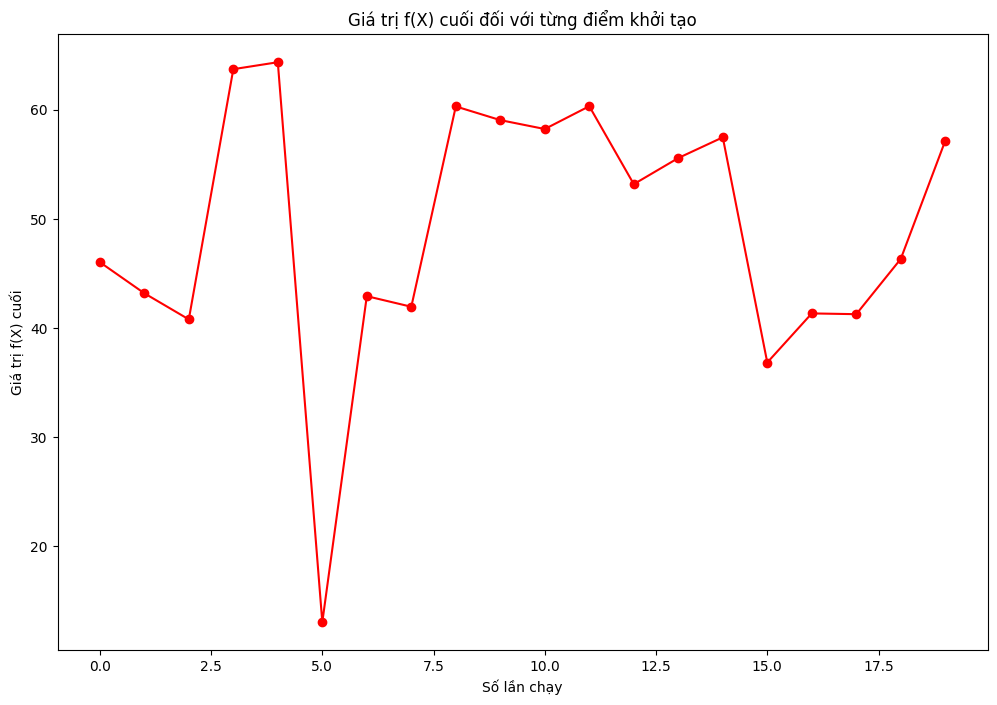

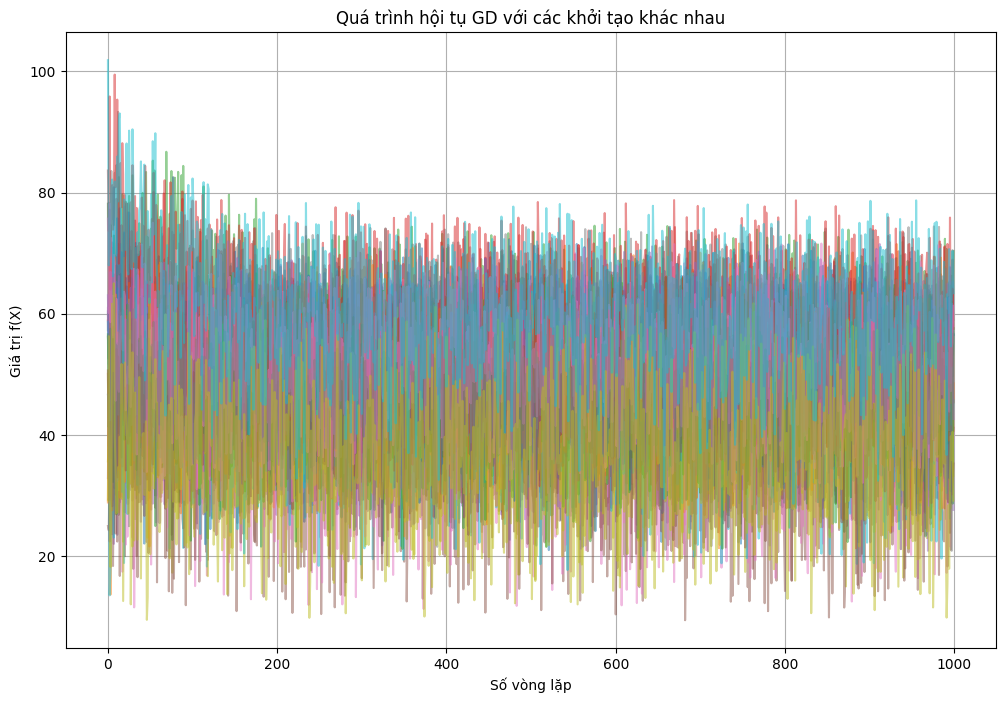

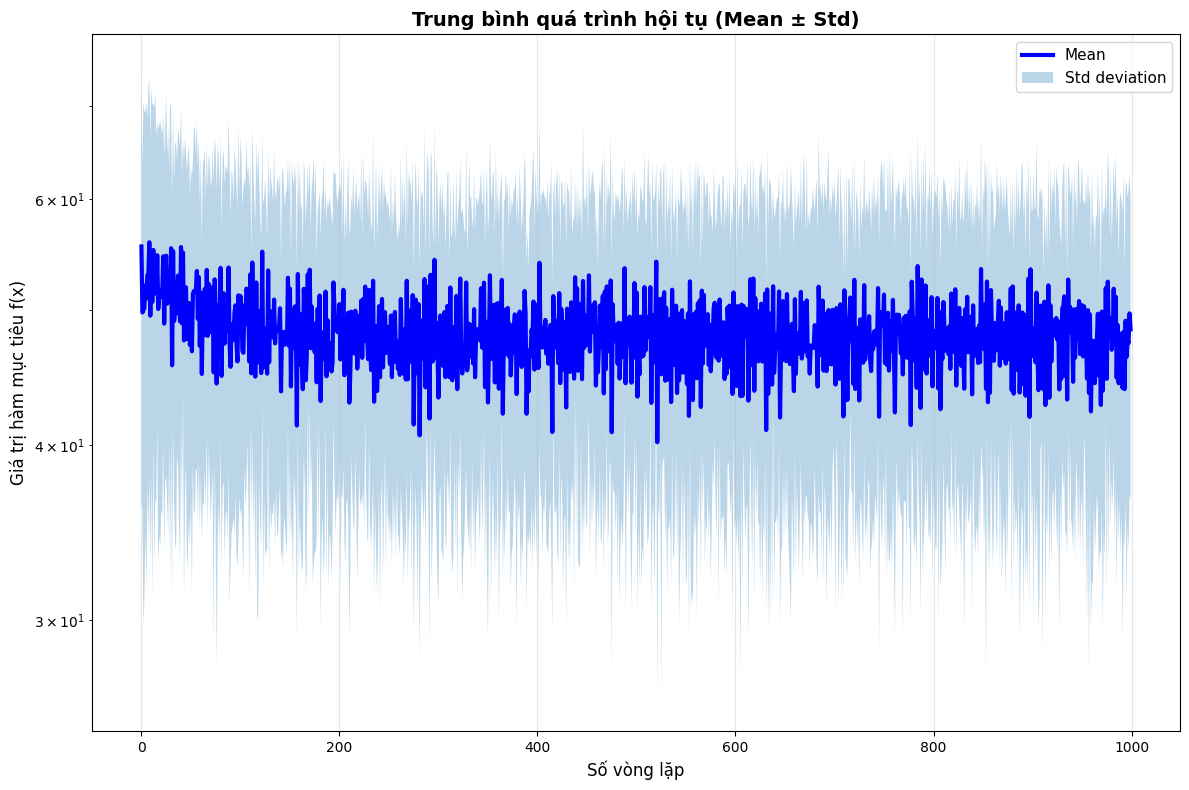


1. TỐC ĐỘ HỘI TỤ:
- Số vòng lặp tối đa: 1000
- Số lần đạt điều kiện dừng sớm: 0/20
- Trung bình số vòng lặp: 1000.0
- Min: 1000, Max: 1000
-> Không hội tụ

2. ĐỘ ỔN ĐỊNH TRONG 1 LẦN CHẠY:
Chương trình 1
Min = 21.5606, Max f(X): 73.2591, Mean f(X): 50.5369, Std f(X): 10.2107, Độ chênh lệch: 51.6985
Độ ổn định = std/mean * 100 (%) = 20.2044
Chương trình 2
Min = 13.6139, Max f(X): 54.2516, Mean f(X): 42.4180, Std f(X): 6.6849, Độ chênh lệch: 40.6377
Độ ổn định = std/mean * 100 (%) = 15.7597
Chương trình 3
Min = 27.2863, Max f(X): 86.7396, Mean f(X): 56.8860, Std f(X): 10.4254, Độ chênh lệch: 59.4533
Độ ổn định = std/mean * 100 (%) = 18.3269
Chương trình 4
Min = 27.4924, Max f(X): 80.1844, Mean f(X): 56.1777, Std f(X): 9.9427, Độ chênh lệch: 52.6920
Độ ổn định = std/mean * 100 (%) = 17.6986
Chương trình 5
Min = 21.9996, Max f(X): 66.1988, Mean f(X): 47.4542, Std f(X): 16.8956, Độ chênh lệch: 44.1992
Độ ổn định = std/mean * 100 (%) = 35.6041
Chương trình 6
Min = 9.3945, Max f(X): 59.2599, 

In [8]:
import numpy as np
import math as m
import matplotlib.pyplot as plt
ln_rate = 0.01
dk_dung = 0.001
max_iter = 1000
run = 20
#X = np.array([1.0, -1.5, 0.5])
giatri_f_cuoi = []
all_f_his = []
d2f_x = 2 + 40 * (np.pi ** 2) * np.cos(2 * np.pi * 0)
def f(X):
    return (30 +
            X[0]*X[0]-10*m.cos(2*np.pi*X[0])+
            X[1]*X[1]-10*m.cos(2*np.pi*X[1])+
            X[2]*X[2]-10*m.cos(2*np.pi*X[2]))



for j in range(run):
    X = np.random.uniform(-5.12, 5.12, 3)
    print("=" * 80)
    print(f'chương trình {j + 1}: \nĐiểm khởi tạo X = {X}')
    f_his = []
    for i in range(max_iter):
        f_his.append(f(X))
        gradf = np.array([
                2*X[0]+20*m.pi*m.sin(2*m.pi*X[0]),
                2*X[1]+20*m.pi*m.sin(2*m.pi*X[1]),
                2*X[2]+20*m.pi*m.sin(2*m.pi*X[2])
                ])
        norm_gradf = m.sqrt(gradf[0]**2 + gradf[1]**2 + gradf[2]**2)
        if(norm_gradf<dk_dung):
            print(f'Đã hội tụ sau lần lặp: {i}')
            break

        X = X - ln_rate*gradf 

    all_f_his.append(f_his)
    giatri_f_cuoi.append(f(X))
    print(f'Giá trị f(x) cuối cùng = {f(X):.4f}')
    
giatri_f_cuoi = np.array(giatri_f_cuoi)
print('\nThống kê sau 20 lần chạy:')
print(f'Min = {giatri_f_cuoi.min():.4f}')
print(f'Max = {giatri_f_cuoi.max():.4f}')
print(f'Mean = {giatri_f_cuoi.mean():.4f}')
print(f'Std = {giatri_f_cuoi.std():.4f}')

#Biểu đồ 1
plt.figure(figsize=(12, 8))
plt.plot(giatri_f_cuoi, 'r-o')
plt.xlabel('Số lần chạy')
plt.ylabel('Giá trị f(X) cuối')
plt.title('Giá trị f(X) cuối đối với từng điểm khởi tạo')
plt.show()

#Biểu đồ 2
plt.figure(figsize=(12, 8))
for k, his in enumerate(all_f_his):
    plt.plot(his, alpha=0.5)

plt.xlabel('Số vòng lặp')
plt.ylabel('Giá trị f(X)')
plt.title('Quá trình hội tụ GD với các khởi tạo khác nhau')
plt.grid(True)
plt.show()

#Biểu đồ 3
plt.figure(figsize=(12, 8))
max_len = max(len(h) for h in all_f_his)
avg_convergence = []
std_convergence = []

for iter_idx in range(max_len):
    values = [h[iter_idx] if iter_idx < len(h) else h[-1] 
              for h in all_f_his]
    avg_convergence.append(np.mean(values))
    std_convergence.append(np.std(values))

avg_convergence = np.array(avg_convergence)
std_convergence = np.array(std_convergence)

plt.plot(avg_convergence, 'b-', linewidth=3, label='Mean')
plt.fill_between(range(max_len), 
                  avg_convergence - std_convergence,
                  avg_convergence + std_convergence,
                  alpha=0.3, label='Std deviation')
plt.xlabel('Số vòng lặp', fontsize=12)
plt.ylabel('Giá trị hàm mục tiêu f(x)', fontsize=12)
plt.title('Trung bình quá trình hội tụ (Mean ± Std)', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('do_thi_2_trung_binh.png', dpi=300, bbox_inches='tight')
plt.show()

#Nhận xét:
#Tốc độ hội tụ
print("\n1. TỐC ĐỘ HỘI TỤ:")
print(f"- Số vòng lặp tối đa: {max_iter}")
k = sum(1 for h in all_f_his if len(h) < max_iter)
print(f"- Số lần đạt điều kiện dừng sớm: {k}/{run}")
avg_iters = np.mean([len(h) for h in all_f_his])
print(f"- Trung bình số vòng lặp: {avg_iters:.1f}")
print(f"- Min: {min(len(h) for h in all_f_his)}, Max: {max(len(h) for h in all_f_his)}")

#Tính p để xét tốc độ hội tụ
p = abs(1 - ln_rate * d2f_x)
if(p >= 0 and p < 0.1):
    print("-> Tốc độ hội tụ rất nhanh")
elif(p >= 0.1 and p < 0.5):
    print("-> Tốc độ hội tụ nhanh")
elif(p >= 0.5 and p < 0.9):
    print("-> Tốc độ hội tụ trung bình")
elif(p >= 0.9 and p < 1):
    print("-> Tốc độ hội tụ chậm")
else:
    print("-> Không hội tụ")


#Độ ổn định theo khởi tạo ban đầu
print("\n2. ĐỘ ỔN ĐỊNH TRONG 1 LẦN CHẠY:")
for i in range(run):
    print("=" * 100)
    print(f"Chương trình {i + 1}")
    print(f"Min = {np.min(all_f_his[i]):.4f}, " 
          f"Max f(X): {np.max(all_f_his[i]):.4f}, "
          f"Mean f(X): {np.mean(all_f_his[i]):.4f}, "
          f"Std f(X): {np.std(all_f_his[i]):.4f}, "
          f"Độ chênh lệch: {np.max(all_f_his[i]) - np.min(all_f_his[i]):.4f}")
    print(f"Độ ổn định = std/mean * 100 (%) = {np.std(all_f_his[i]) / np.mean(all_f_his[i]) * 100:.4f}")

#Khả năng tìm nghiệm toàn cục:
print("\n3. KHẢ NĂNG TÌM NGHIỆM TOÀN CỤC")
print("Sau 20 lần chạy")
print("Nghiệm tối ưu lý thuyết: f(0,0,0) = 0")
print(f"Nghiệm tốt ưu tìm được: {giatri_f_cuoi.min():.4f}")
print(f"Sai số: {giatri_f_cuoi.min():.4f}")
print(f"Phân tích từng chương trình chạy:")
for i in range (run):
    print("=" * 150)
    print(f"Chương trình {i + 1}")
    print(f"Số lần f(x) < 1.0: {sum(1 for h in all_f_his[i] if h < 1)}, "
          f"f(x) < 5.0: {sum(1 for h in all_f_his[i] if h < 5)}, "
          f"f(x) < 10.0: {sum(1 for h in all_f_his[i] if h < 10)}, "
          f"f(x) < 20.0: {sum(1 for h in all_f_his[i] if h < 20)}, "
          f"f(x) < 40.0: {sum(1 for h in all_f_his[i] if h < 40)}, "
          f"f(x) < 50.0: {sum(1 for h in all_f_his[i] if h < 50)}, "
          f"f(x) < 80.0: {sum(1 for h in all_f_his[i] if h < 80)}, "
          f"f(x) < 100.0: {sum(1 for h in all_f_his[i] if h < 100)}")


